# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')
import os

In [23]:
train_path = "../data/fashion-mnist_train.csv"
test_path = "../data/fashion-mnist_test.csv"

mnist_train = pd.read_csv(train_path)
mnist_test = pd.read_csv(test_path)

# 2. Initial Exploration

In [24]:
X_train = mnist_train.iloc[:, 1:].values
y_train = mnist_train.iloc[:, 0].values
X_test = mnist_test.iloc[:, 1:].values
y_test = mnist_test.iloc[:, 0].values

# Normalization: Scaling pixel values from 0-255 to 0-1.
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

print(f"\nThe range of pixel values in the normalized training set: [{X_train_normalized.min():.3f}, {X_train_normalized.max():.3f}]")


The range of pixel values in the normalized training set: [0.000, 1.000]


In [25]:
class SimplePerceptron:
    def __init__(self, input_size, output_size):
        # Initialize the weight matrix with a shape of (input_size, output_size).
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.bias = np.zeros((1, output_size))
    
    def forward(self, x):
        # 加权求和
        z = np.dot(x, self.weights) + self.bias
        # 通过激活函数（使用Softmax，将输出转为概率，用于多分类）
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def predict(self, x):
        probabilities = self.forward(x)
        return np.argmax(probabilities, axis=1)

# 初始化网络：784个输入，10个输出
input_size = 784
output_size = 10
simple_model = SimplePerceptron(input_size, output_size)

sample_input = X_train_normalized[:5]
predictions = simple_model.forward(sample_input)
print("\nThe predicted probability distribution of the first 5 images (each row sums up to 1):")
print(predictions)
print("\nThe predicted category is:", simple_model.predict(sample_input))
print("The actual label is:", y_train[:5])


The predicted probability distribution of the first 5 images (each row sums up to 1):
[[0.11405057 0.07616288 0.0981729  0.09661225 0.08337918 0.1265912
  0.11444025 0.09375    0.08769811 0.10914265]
 [0.1193858  0.08656574 0.10499539 0.09594078 0.09470456 0.11150453
  0.11804531 0.08983616 0.08209379 0.09692795]
 [0.09589626 0.08044058 0.08928774 0.11460723 0.08076933 0.11481546
  0.13005868 0.10721208 0.09054549 0.09636714]
 [0.11566541 0.0928508  0.09226615 0.09393109 0.088718   0.096512
  0.11932881 0.09173602 0.11032209 0.09866963]
 [0.09822466 0.08415642 0.09763198 0.09439715 0.08865447 0.11239414
  0.12659371 0.09703457 0.10154697 0.09936593]]

The predicted category is: [5 0 6 6 6]
The actual label is: [2 9 6 0 3]



Data augmentation examples (enhanced versions of the first 5 images)：


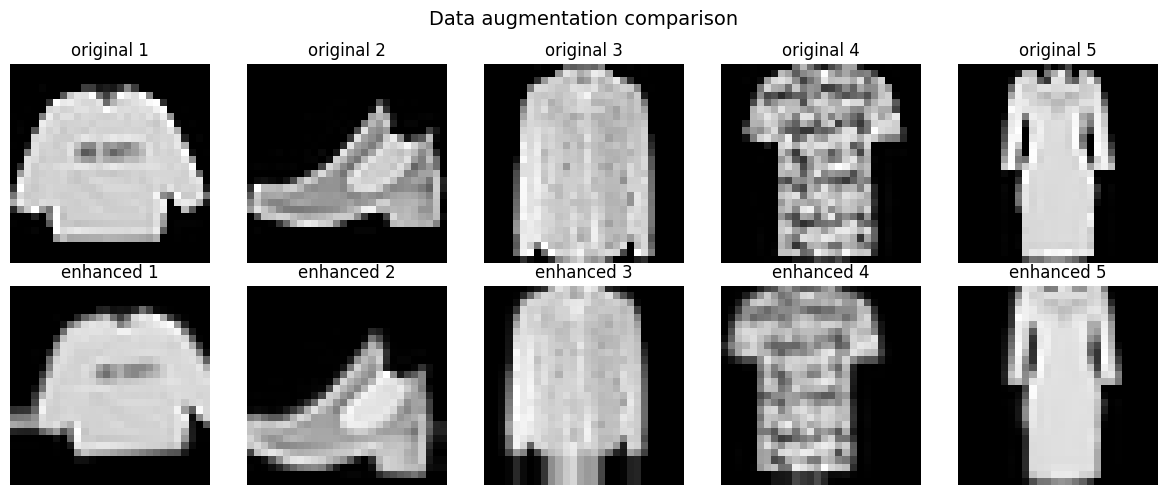

In [26]:
# ==================== 4. 数据增强（扩展数据集） ====================
# 将训练集数据重塑为图像格式 (28x28)
X_train_images = X_train_normalized.reshape(-1, 28, 28, 1)

# 使用Keras的ImageDataGenerator进行数据增强
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 创建数据增强器（轻微旋转、平移、缩放）
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

print("\nData augmentation examples (enhanced versions of the first 5 images)：")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    original_img = X_train_images[i].reshape(28, 28)
    augmented_img = datagen.random_transform(X_train_images[i]).reshape(28, 28)
    
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].set_title(f"original {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(augmented_img, cmap='gray')
    axes[1, i].set_title(f"enhanced {i+1}")
    axes[1, i].axis('off')
plt.suptitle("Data augmentation comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
# ==================== 5. 使用Keras构建多层神经网络 ====================
model = keras.Sequential([
    # 输入层：将一维的784个像素点输入网络
    keras.layers.Input(shape=(784,)),
    
    # 第一个隐藏层：128个神经元，使用ReLU激活函数
    keras.layers.Dense(128, activation='relu', name='hidden_layer_1'),
    
    # Dropout层：防止过拟合
    keras.layers.Dropout(0.2, name='dropout_1'),
    
    # 第二个隐藏层：64个神经元，使用ReLU激活函数
    keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),
    
    # Dropout层
    keras.layers.Dropout(0.2, name='dropout_2'),
    
    # 输出层：10个神经元，使用Softmax激活函数得到类别概率
    keras.layers.Dense(10, activation='softmax', name='output_layer')
])

# 编译模型：指定优化器、损失函数和评估指标
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 查看模型结构摘要
print("\nSummary of Model Structure:")
model.summary()


Summary of Model Structure:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

The neural network model structure for dataset construction consists of two fully connected layers and Dropout regularization, with a total of approximately 109K parameters. The purpose is to verify and confirm that it is suitable for subsequent image classification training.

In [28]:
# ==================== 6. 训练和评估模型 ====================
# 设置训练参数
epochs = 10
batch_size = 32
validation_split = 0.2  # 使用20%的训练数据作为验证集

# 训练模型
print(f"\nStart training...")
print(f"Training parameters: epochs={epochs}, batch_size={batch_size}, validation_split={validation_split}")

history = model.fit(
    X_train_normalized, 
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1
)

#模型评估
print("\nEvaluating the model on the test set...")
test_loss, test_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
print(f"Test set loss: {test_loss:.4f}")
print(f"Accuracy of the test set: {test_acc:.4f}")


Start training...
Training parameters: epochs=10, batch_size=32, validation_split=0.2
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7797 - loss: 0.6169 - val_accuracy: 0.8479 - val_loss: 0.4222
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8386 - loss: 0.4439 - val_accuracy: 0.8461 - val_loss: 0.4186
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8516 - loss: 0.4074 - val_accuracy: 0.8667 - val_loss: 0.3681
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8605 - loss: 0.3844 - val_accuracy: 0.8716 - val_loss: 0.3519
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8655 - loss: 0.3660 - val_accuracy: 0.8723 - val_loss: 0.3432
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8713 - loss: 0.3528 - val_accuracy: 0.8805 - val_loss: 0.3421
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8763 - loss: 0.3380 - val_accuracy: 0.8808 - val_loss: 0.3355
Epo

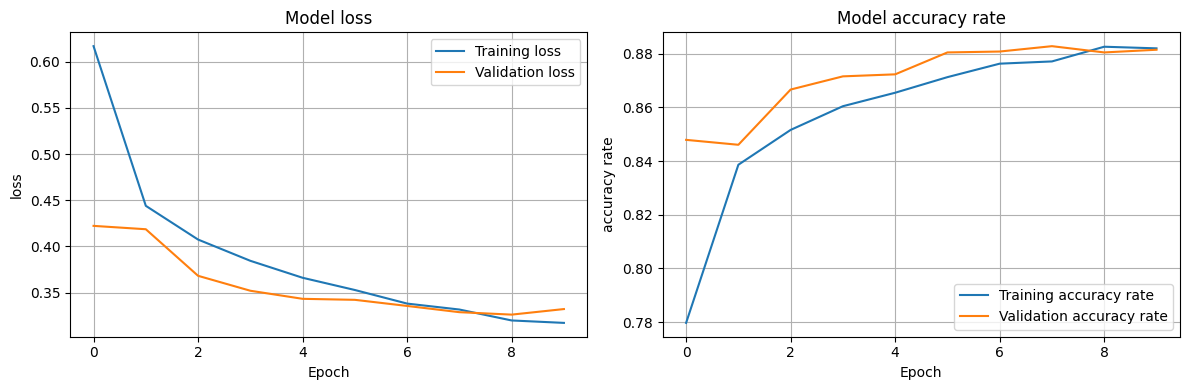

In [29]:
# ==================== 7. 可视化训练过程 ====================
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 绘制损失曲线
    ax1.plot(history.history['loss'], label='Training loss')
    ax1.plot(history.history['val_loss'], label='Validation loss')
    ax1.set_title('Model loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('loss')
    ax1.legend()
    ax1.grid(True)
    
    # 绘制准确率曲线
    ax2.plot(history.history['accuracy'], label='Training accuracy rate')
    ax2.plot(history.history['val_accuracy'], label='Validation accuracy rate')
    ax2.set_title('Model accuracy rate')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('accuracy rate')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

The curves of loss and accuracy during training and validation both improved rapidly and then stabilized, showing that the model effectively converged and there was no overfitting.

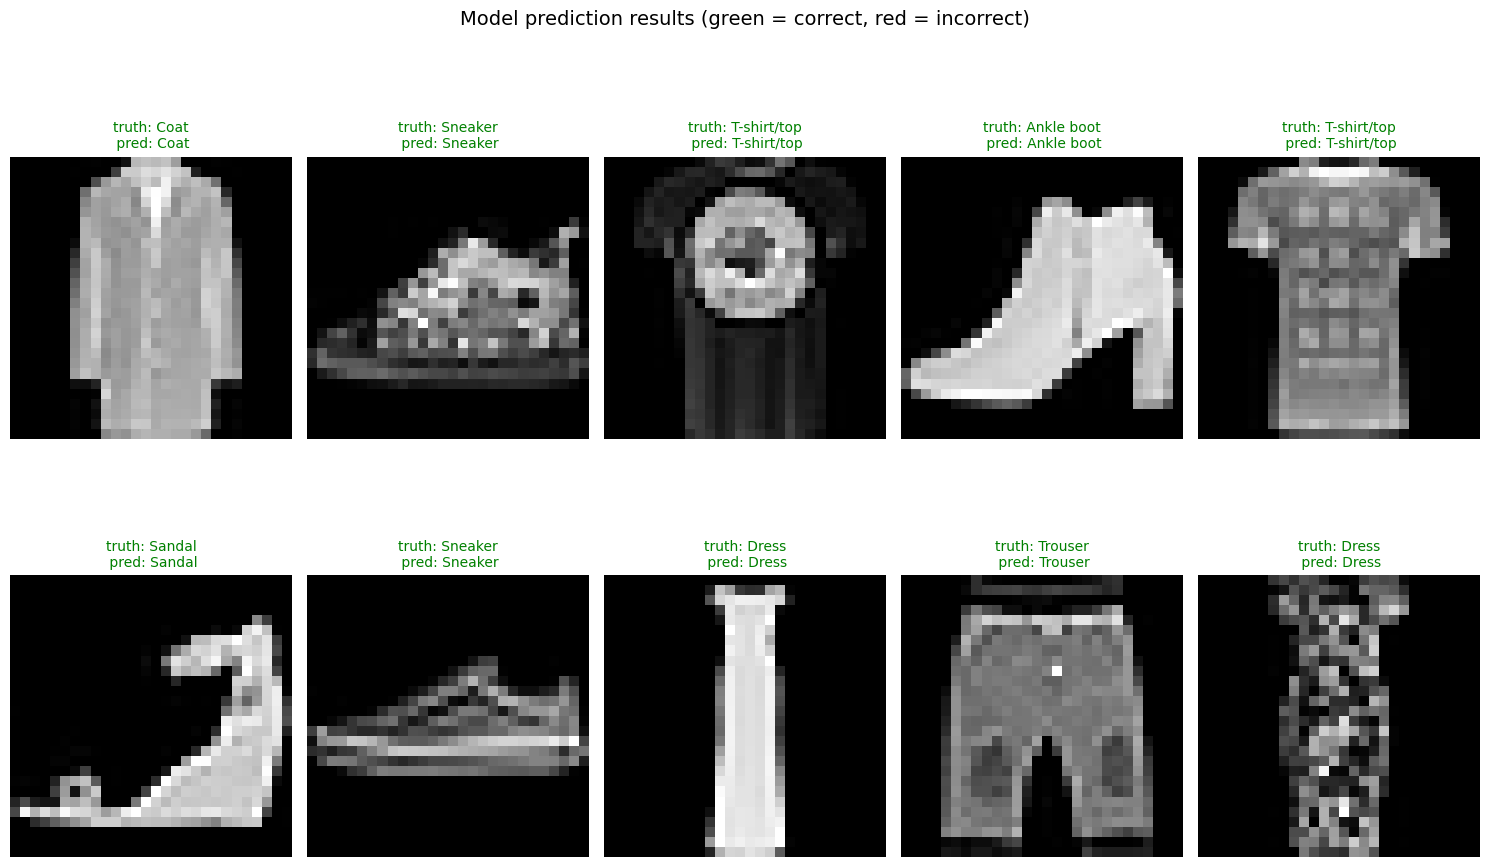

In [30]:
# ==================== 10. 进行预测 ====================
num_samples = 10
if X_test is not None:
    sample_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)
    sample_images = X_test_normalized[sample_indices]
    sample_labels = y_test[sample_indices]
else:
    # 如果没有测试集，使用训练集的后一部分
    sample_indices = np.random.choice(len(X_train_normalized) - 1000, num_samples, replace=False) + 1000
    sample_images = X_train_normalized[sample_indices]
    sample_labels = y_train[sample_indices]

# 进行预测
predictions = model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# 可视化预测结果
plt.figure(figsize=(15, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    
    # 判断预测是否正确
    color = 'green' if predicted_classes[i] == sample_labels[i] else 'red'
    
    plt.title(f"truth: {class_names[sample_labels[i]]}\n pred: {class_names[predicted_classes[i]]}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('Model prediction results (green = correct, red = incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# ==================== 6.1 构建卷积神经网络（CNN） ====================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 重塑数据为CNN需要的格式 (样本数, 高度, 宽度, 通道数)
X_train_cnn = X_train_normalized.reshape(-1, 28, 28, 1)
if X_test is not None:
    X_test_cnn = X_test_normalized.reshape(-1, 28, 28, 1)

# 构建CNN模型
cnn_model = Sequential([
    # 第一卷积层（PDF第14页提到的隐藏层概念）
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    
    # 第二卷积层
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    
    # 第三卷积层
    Conv2D(64, (3, 3), activation='relu', name='conv3'),
    
    # 展平层，将3D特征图转为1D
    Flatten(name='flatten'),
    
    # 全连接层（密集层）
    Dense(64, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout'),
    
    # 输出层（10个类别）
    Dense(10, activation='softmax', name='output')
])

# 编译模型
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nSummary of CNN Model Structure:")
cnn_model.summary()


Summary of CNN Model Structure:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

The CNN model architecture (comprising 3 convolutional layers, with approximately 93K parameters in total) clearly presents the structure of each layer of the model, the changes in data flow, and the scale of parameters.

In [32]:
# ==================== 7.1 训练CNN模型 ====================
# 使用数据增强器训练CNN
train_generator = datagen.flow(
    X_train_cnn, 
    y_train, 
    batch_size=32
)

# 训练CNN模型
cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_cnn) // 32,
    epochs=10,
    validation_data=(X_test_cnn.reshape(-1, 28, 28, 1), y_test) if X_test is not None else None,
    verbose=1
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.6856 - loss: 0.8438 - val_accuracy: 0.8121 - val_loss: 0.4735
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7801 - loss: 0.5849 - val_accuracy: 0.8308 - val_loss: 0.4222
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8099 - loss: 0.5157 - val_accuracy: 0.8641 - val_loss: 0.3572
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8283 - loss: 0.4718 - val_accuracy: 0.8637 - val_loss: 0.3500
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8372 - loss: 0.4454 - val_accuracy: 0.8703 - val_loss: 0.3313
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8476 - loss: 0.4231 - val_accuracy: 0.8844 - val_loss: 0.3079
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8540 - loss: 0.4056 - val_accuracy: 0.8905 - val_loss: 0.2859
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8584 - loss


Model performance comparison:
Model type      Test loss    Test accuracy
----------------------------------------
MLP             0.3219      0.8819
CNN             0.2870      0.8926


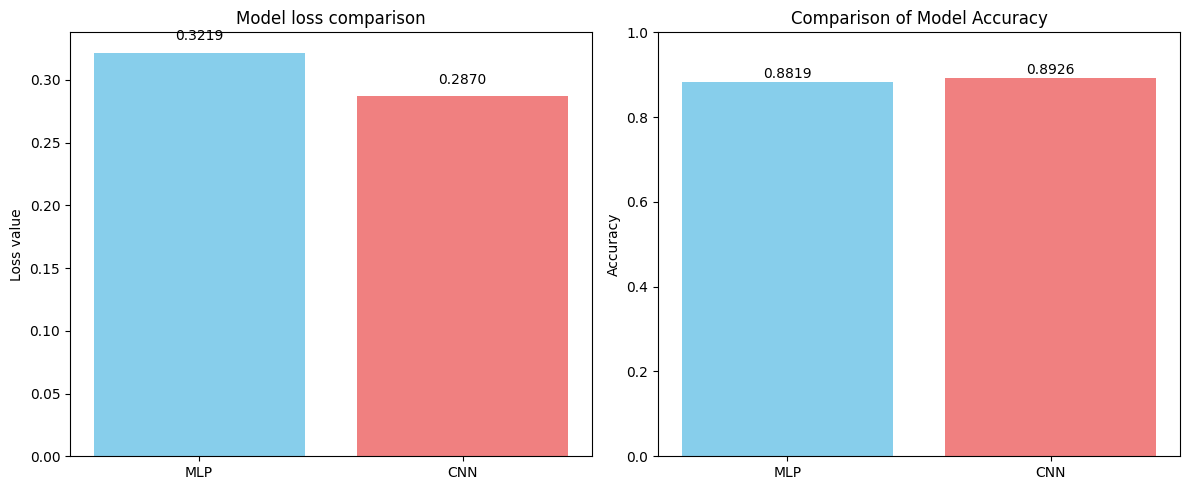

In [33]:
# ==================== 8.1 模型对比分析 ====================
# 对比两种模型的性能
if X_test is not None:
    # 评估多层感知机（MLP）
    mlp_loss, mlp_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
    
    # 评估卷积神经网络（CNN）
    cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
    
    print("\nModel performance comparison:")
    print(f"{'Model type':<15} {'Test loss':<12} {'Test accuracy':<12}")
    print("-" * 40)
    print(f"{'MLP':<15} {mlp_loss:.4f}      {mlp_acc:.4f}")
    print(f"{'CNN':<15} {cnn_loss:.4f}      {cnn_acc:.4f}")
    
    # 绘制对比柱状图
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # 损失对比
    models = ['MLP', 'CNN']
    losses = [mlp_loss, cnn_loss]
    ax[0].bar(models, losses, color=['skyblue', 'lightcoral'])
    ax[0].set_title('Model loss comparison')
    ax[0].set_ylabel('Loss value')
    for i, v in enumerate(losses):
        ax[0].text(i, v + 0.01, f'{v:.4f}', ha='center')
    # 准确率对比
    accuracies = [mlp_acc, cnn_acc]
    ax[1].bar(models, accuracies, color=['skyblue', 'lightcoral'])
    ax[1].set_title('Comparison of Model Accuracy')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_ylim([0, 1])
    for i, v in enumerate(accuracies):
        ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.show()

The classification performance of MLP and CNN on Fashion MNIST was compared. The results showed that CNN was slightly superior to MLP in terms of test loss (0.2870 < 0.3219) and accuracy (0.8926 > 0.8819), demonstrating the effectiveness of the CNN architecture in extracting image features.

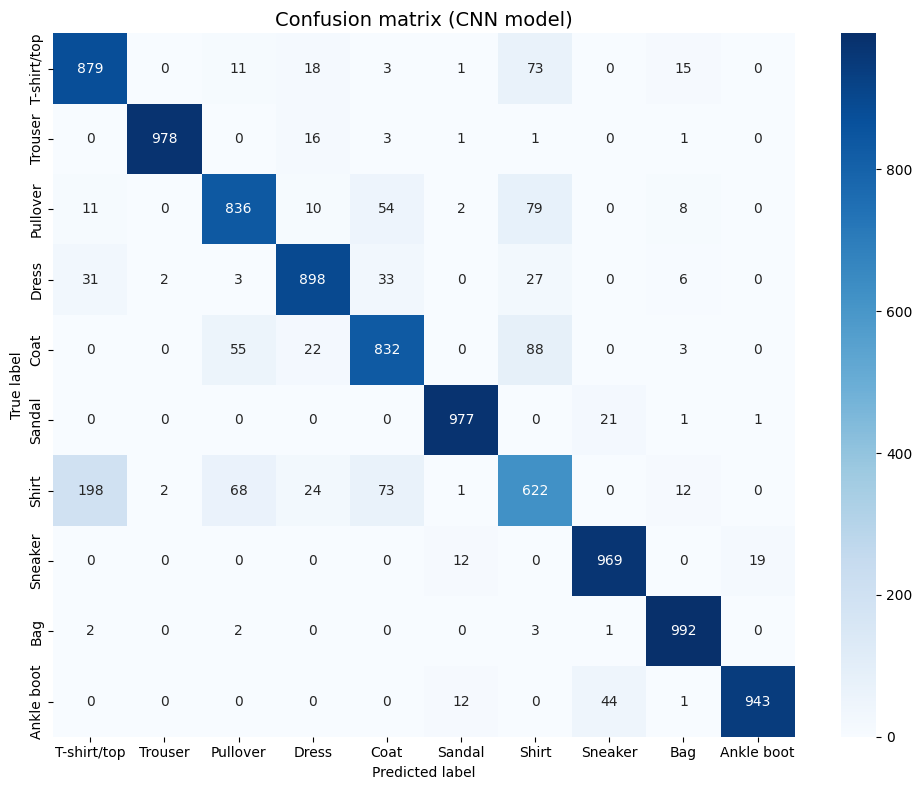


The most common misclassifications (the top 5)：
True: Shirt           → Pred: T-shirt/top     Count: 198
True: Coat            → Pred: Shirt           Count: 88
True: Pullover        → Pred: Shirt           Count: 79
True: T-shirt/top     → Pred: Shirt           Count: 73
True: Shirt           → Pred: Coat            Count: 73


In [34]:
# ==================== 9.1 混淆矩阵分析 ====================
if X_test is not None:
    # 获取CNN模型的预测结果
    cnn_predictions = cnn_model.predict(X_test_cnn, verbose=0)
    cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)
    
    # 计算混淆矩阵
    cm = confusion_matrix(y_test, cnn_predicted_classes)
    
    # 绘制混淆矩阵热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion matrix (CNN model)', fontsize=14)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()
    # 分析最常见的误分类
    print("\nThe most common misclassifications (the top 5)：")
    misclassified = []
    for i in range(len(y_test)):
        if y_test[i] != cnn_predicted_classes[i]:
            misclassified.append((y_test[i], cnn_predicted_classes[i]))
    
    from collections import Counter
    top_misclass = Counter(misclassified).most_common(5)
    
    for (true, pred), count in top_misclass:
        print(f"True: {class_names[true]:<15} → Pred: {class_names[pred]:<15} Count: {count}")

The confusion matrix evaluated the classification performance of the CNN model for ten types of clothing and identified the easily confused categories. The overall accuracy of the model was high, but there were significant misclassifications in visually similar categories (such as "shirt" and "T-shirt", "coat").


The convolution kernels of the first convolutional layer (part):


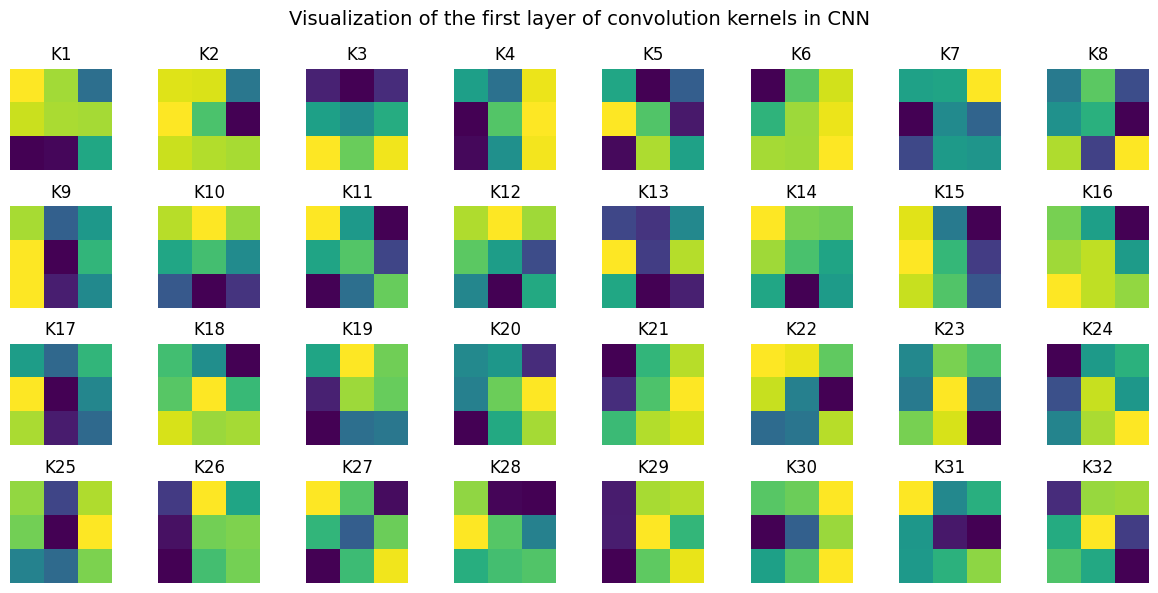

In [35]:
# ==================== 10.1 特征可视化 ====================
# 提取CNN第一层的卷积核和特征图
first_layer = cnn_model.layers[0]
weights = first_layer.get_weights()[0]  # 卷积核权重

# 可视化第一层的卷积核
print("\nThe convolution kernels of the first convolutional layer (part):")
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i in range(32):  # 前32个卷积核
    if i >= 32:
        break
    row, col = divmod(i, 8)
    if row >= 4:
        break
    
    kernel = weights[:, :, 0, i]  # 获取第i个卷积核
    axes[row, col].imshow(kernel, cmap='viridis')
    axes[row, col].axis('off')
    axes[row, col].set_title(f'K{i+1}')

plt.suptitle('Visualization of the first layer of convolution kernels in CNN', fontsize=14)
plt.tight_layout()
plt.show()


Intuitively display the weight distribution learned by the first layer of convolutional kernels in CNN; The 32 3x3 convolutional kernels in the running result show different directions and intensities, indicating that the model has initially learned to capture basic visual features such as edges and textures.